In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import statsmodels.api as sm

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving car_evaluation.csv to car_evaluation.csv


In [ ]:
import io

DataSet = pd.read_csv(io.BytesIO(uploaded['car_evaluation.csv']), on_bad_lines='skip', encoding='latin-1')

In [ ]:
DataSet.shape[0]

1727

In [ ]:
DataSet.describe()

,vhigh,vhigh.1,2,2.1,small,low,unacc
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,4
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


In [ ]:
print(DataSet.dtypes)

vhigh      object
vhigh.1    object
2          object
2.1        object
small      object
low        object
unacc      object
dtype: object


In [ ]:
DataSet.isnull().sum()

,0
vhigh,0
vhigh.1,0
2,0
2.1,0
small,0
low,0
unacc,0


In [ ]:
DataSet.duplicated().sum()

np.int64(0)

In [ ]:
duplicates = DataSet[DataSet.duplicated()]
duplicates

,vhigh,vhigh.1,2,2.1,small,low,unacc


In [ ]:
duplicates = DataSet[DataSet.duplicated(keep=False)]

duplicate_count = len(duplicates) // 2

if duplicate_count == 0:
    print("✅ No fully identical rows found in the dataset.")
else:
    print(f"⚠️ {duplicate_count} pairs of 100% identical rows found.")
    print("\nHere are the fully duplicated rows:")
    display(duplicates.head())


✅ No fully identical rows found in the dataset.


In [ ]:
DataSet.notnull().sum()

,0
phone_brand,1708
phone_model,1708
store,1708
price_usd,1708
storage,1708
ram,1708
launch_date,1708
dimensions,1708
weight,1708
display_type,1708


In [ ]:
DataSet["launch_year"] = pd.to_datetime(DataSet["year"]).dt.year

In [ ]:
num_cols = ["ram", "storage", "battery", "ppi_density"]

for col in num_cols:
    col_min = DataSet[col].min()
    col_max = DataSet[col].max()
    DataSet[col + "_norm"] = (DataSet[col] - col_min) / (col_max - col_min)

DataSet["spec_index"] = DataSet[[c + "_norm" for c in num_cols]].mean(axis=1)


In [ ]:
cluster_features = ["ram", "storage", "battery", "display_size", "ppi_density", "weight", "spec_index"]

DataSet_cluster = DataSet.copy()
for col in cluster_features:
    col_min = DataSet_cluster[col].min()
    col_max = DataSet_cluster[col].max()
    DataSet_cluster[col + "_scaled"] = (DataSet_cluster[col] - col_min) / (col_max - col_min)


In [ ]:
# RAM
DataSet["ram_cat"] = pd.cut(
    DataSet["ram"],
    bins=[0, 4, 8, 100],
    labels=["Low RAM (≤4GB)", "Mid RAM (5–8GB)", "High RAM (>8GB)"],
    include_lowest=True
)

# Storage
DataSet["storage_cat"] = pd.cut(
    DataSet["storage"],
    bins=[0, 128, 256, 5000],
    labels=["Low Storage (≤128GB)", "Mid Storage (129–256GB)", "High Storage (>256GB)"],
    include_lowest=True
)

# Battery
DataSet["battery_cat"] = pd.cut(
    DataSet["battery"],
    bins=[0, 4000, 5000, 20000],
    labels=["Small Battery (≤4000mAh)", "Mid Battery (4001–5000mAh)", "Big Battery (>5000mAh)"],
    include_lowest=True
)

# Display size
DataSet["display_size_cat"] = pd.cut(
    DataSet["display_size"],
    bins=[0, 6.0, 6.7, 20],
    labels=["Small Display (≤6.0\")", "Medium Display (6.1–6.7\")", "Large Display (>6.7\")"],
    include_lowest=True
)

# Price (your own bin, aside from price_range)
DataSet["price_usd_cat"] = pd.cut(
    DataSet["price_usd"],
    bins=[0, 300, 600, 100000],
    labels=["Budget (≤$300)", "Mid ($301–$600)", "High (>$600)"],
    include_lowest=True
)


In [ ]:
rule_cols = [
    "phone_brand",
    "price_range",
    "price_usd_cat",
    "value_segment",
    "ram_cat",
    "storage_cat",
    "battery_cat",
    "display_size_cat",
    "os_type",
    "foldable",
    "fingerprint",
    "chip_company",
    "gpu_company",
    "nfc",
    "usb",
]

DataSet_rules = DataSet[rule_cols].copy()

# Make 0/1 more readable for rules
DataSet_rules["foldable"] = DataSet_rules["foldable"].map({0: "Non-foldable", 1: "Foldable"})
DataSet_rules["nfc"] = DataSet_rules["nfc"].map({0: "No NFC", 1: "Has NFC"})


In [ ]:
DataSet[["price_usd", "quantile_50", "price_vs_median_ratio"]].head()

,price_usd,quantile_50,price_vs_median_ratio
0,1357.55,550.45,2.466255
1,1492.55,550.45,2.711509
2,1705.32,550.45,3.098047
3,1564.92,550.45,2.842983
4,247.32,196.81,1.256643


In [ ]:
DataSet[["price_usd", "quantile_50", "price_vs_median_ratio", "value_segment"]].head()


,price_usd,quantile_50,price_vs_median_ratio,value_segment
0,1357.55,550.45,2.466255,Overpriced
1,1492.55,550.45,2.711509,Overpriced
2,1705.32,550.45,3.098047,Overpriced
3,1564.92,550.45,2.842983,Overpriced
4,247.32,196.81,1.256643,Overpriced


In [ ]:
DataSet["value_segment"].value_counts()


,count
value_segment,
Overpriced,777
Underpriced,758
Fairly Priced,173


In [ ]:
price_map = {
    "low price": 1,
    "medium price": 2,
    "high price": 3
}

DataSet_cluster["price_range_num"] = DataSet_cluster["price_range"].map(price_map)


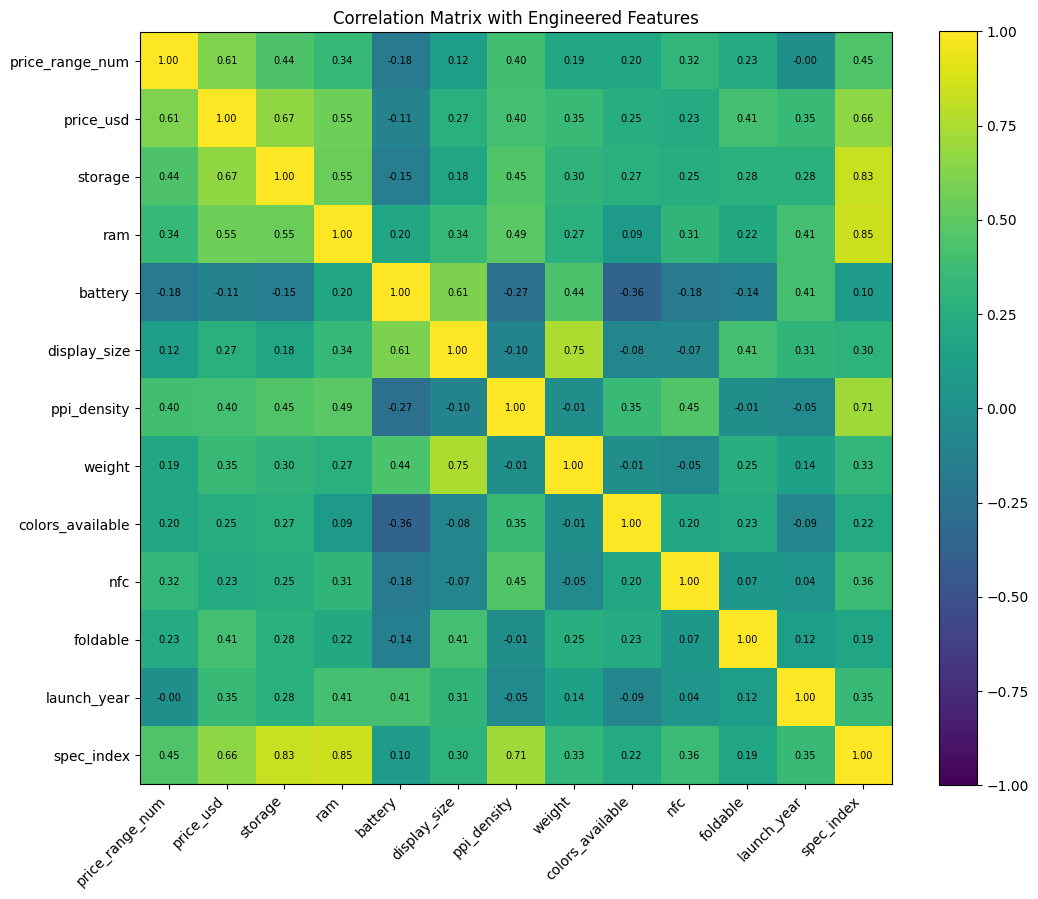

In [ ]:
corr_cols = [
    "price_range_num",
    "price_usd",
    "storage", "ram", "battery", "display_size", "ppi_density", "weight",
    "colors_available", "nfc", "foldable",
    "launch_year",      # engineered
    "spec_index"        # engineered
]

# Ensure 'launch_year' is in DataSet
# Assuming 'year' column exists in DataSet
if "launch_year" not in DataSet.columns:
    DataSet["launch_year"] = pd.to_datetime(DataSet["year"]).dt.year

# Ensure 'spec_index' and its dependencies are in DataSet
num_cols = ["ram", "storage", "battery", "ppi_density"] # Defined here for self-containment
for col in num_cols:
    if col + "_norm" not in DataSet.columns:
        col_min = DataSet[col].min()
        col_max = DataSet[col].max()
        DataSet[col + "_norm"] = (DataSet[col] - col_min) / (col_max - col_min)
if "spec_index" not in DataSet.columns:
    DataSet["spec_index"] = DataSet[[c + "_norm" for c in num_cols]].mean(axis=1)

# Ensure 'price_range_num' is in DataSet
price_map = { # Defined here for self-containment
    "low price": 1,
    "medium price": 2,
    "high price": 3
}
if "price_range_num" not in DataSet.columns:
    DataSet["price_range_num"] = DataSet["price_range"].map(price_map)

# Use DataSet instead of DataSet_cluster
corr = DataSet[corr_cols].corr()

plt.figure(figsize=(11, 9))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.xticks(np.arange(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(np.arange(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.values[i, j]:.2f}",
                 ha="center", va="center", fontsize=7)

plt.title("Correlation Matrix with Engineered Features")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
DataSet.to_csv("processed_data2_with_value_segment.csv", index=False)

In [ ]:
import os

print("Current folder:", os.getcwd())
print(os.listdir())


Current folder: /content
['.config', 'processed_data2 (1).csv', 'processed_data2 (2).csv', 'processed_data2.csv', 'processed_data2_with_value_segment.csv', 'sample_data']


In [ ]:
from google.colab import files
files.download("processed_data2_with_value_segment.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>